In [1]:
import yaml
import torch
import subprocess
from pathlib import Path
from datasets import load_from_disk
from diffusers import StableDiffusionPipeline, DDPMScheduler
from diffusers.loaders import AttnProcsLayers
from diffusers.models.attention_processor import LoRAAttnProcessor
from transformers import CLIPTokenizer, CLIPTextModel
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR
from torchvision import transforms
from peft import LoraConfig

In [2]:
CONFIG_PATH = Path("/data/tla141/INF3600/SwatchMagic/training/training_config.yaml")

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

MODEL_ID            = config["model_id"]
DATASET_PATH        = config["dataset_path"]
OUTPUT_DIR          = Path(config["output_dir"])
LEARNING_RATE       = config["learning_rate"]
NUM_EPOCHS          = config["num_epochs"]
BATCH_SIZE          = config["batch_size"]
LORA_RANK           = config["lora_rank"]
IMAGE_SIZE          = config["image_size"]
MIXED_PRECISION     = config["mixed_precision"]
LR_SCHEDULER        = config.get("lr_scheduler", "none")
EVAL_EVERY          = config.get("eval_every_n_epochs", 5)
VAL_DATASET_PATH    = config.get("val_dataset_path", "data/dataset/hf_dataset_val")
TRAIN_META_PATH     = config.get("train_meta_path", "data/dataset/metadata.json")
EVAL_OUTPUT_DIR     = config.get("eval_output_dir", "evaluation")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Config loaded:")
for k, v in config.items():
    print(f"  {k}: {v}")


Config loaded:
  model_id: runwayml/stable-diffusion-v1-5
  dataset_path: /data/tla141/INF3600/SwatchMagic/data/dataset/hf_dataset
  output_dir: weights/lora_weights_run_A
  learning_rate: 0.0001
  num_epochs: 20
  batch_size: 4
  lora_rank: 8
  image_size: 512
  mixed_precision: fp16
  lr_scheduler: cosine
  eval_every_n_epochs: 5
  val_dataset_path: data/dataset/hf_dataset_val
  train_meta_path: data/dataset/metadata.json
  eval_output_dir: evaluation


In [3]:

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:
print("Loading model...")
tokenizer    = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder").to(DEVICE)
pipeline     = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
)
unet             = pipeline.unet.to(DEVICE)
vae              = pipeline.vae.to(DEVICE)
noise_scheduler  = DDPMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")
print("Model loaded.")

Loading model...


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

/data/tla141/INF3600/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Model loaded.


In [5]:
# Freeze everything except LoRA layers
vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True, bias=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True, bias=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_features=320, bias=False)
                (to_v): Linear(i

In [6]:
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_RANK,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)
unet.add_adapter(lora_config)
lora_layers = [p for p in unet.parameters() if p.requires_grad]

In [7]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

def preprocess(example):
    example["pixel_values"] = transform(example["image"].convert("RGB"))
    tokens = tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=77,
        return_tensors="pt"
    )
    example["input_ids"] = tokens.input_ids[0]
    return example

print("Loading and splitting dataset...")
full_dataset = load_from_disk(DATASET_PATH)
full_dataset = full_dataset.map(preprocess, remove_columns=["image", "text"])
full_dataset.set_format("torch")

# 80/20 train/val split
split        = full_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split["train"]
val_dataset   = split["test"]

# Save val split to disk so evaluate_checkpoint.py can load it
val_dataset.save_to_disk(VAL_DATASET_PATH)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} samples | Val: {len(val_dataset)} samples")

Loading and splitting dataset...


Saving the dataset (0/2 shards):   0%|          | 0/260 [00:00<?, ? examples/s]

Train: 1038 samples | Val: 260 samples


In [8]:
optimizer = AdamW(lora_layers, lr=LEARNING_RATE)

if LR_SCHEDULER == "cosine":
    scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    print(f"LR scheduler: CosineAnnealingLR (T_max={NUM_EPOCHS})")
elif LR_SCHEDULER == "linear":
    scheduler = LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=NUM_EPOCHS)
    print(f"LR scheduler: LinearLR (1.0 → 0.1 over {NUM_EPOCHS} epochs)")
else:
    scheduler = None
    print("LR scheduler: none (constant LR)")

LR scheduler: CosineAnnealingLR (T_max=20)


In [9]:
# Loss log: will be written to OUTPUT_DIR/loss_log.csv
loss_log_path = OUTPUT_DIR / "loss_log_C.csv"
with open(loss_log_path, "w") as f:
    f.write("epoch,train_loss,val_loss,lr\n")

print("Starting training...")

for epoch in range(NUM_EPOCHS):

    # ── Training ──────────────────────────────────────────────────────────
    unet.train()
    total_train_loss = 0

    for step, batch in enumerate(train_dataloader):
        pixel_values = batch["pixel_values"].to(DEVICE)
        input_ids    = batch["input_ids"].to(DEVICE)

        with torch.no_grad():
            latents = vae.encode(pixel_values).latent_dist.sample() * 0.18215

        noise         = torch.randn_like(latents)
        timesteps     = torch.randint(
            0, noise_scheduler.config.num_train_timesteps,
            (latents.shape[0],), device=DEVICE
        ).long()                                          # fix: was `device` (undefined)
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        with torch.no_grad():
            encoder_hidden_states = text_encoder(input_ids)[0]

        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
        loss = torch.nn.functional.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_dataloader)

    # ── Validation loss ───────────────────────────────────────────────────
    unet.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in val_dataloader:
            pixel_values = batch["pixel_values"].to(DEVICE)
            input_ids    = batch["input_ids"].to(DEVICE)

            latents = vae.encode(pixel_values).latent_dist.sample() * 0.18215
            noise   = torch.randn_like(latents)
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps,
                (latents.shape[0],), device=DEVICE
            ).long()
            noisy_latents         = noise_scheduler.add_noise(latents, noise, timesteps)
            encoder_hidden_states = text_encoder(input_ids)[0]
            noise_pred            = unet(noisy_latents, timesteps, encoder_hidden_states).sample
            total_val_loss       += torch.nn.functional.mse_loss(noise_pred, noise).item()

    avg_val_loss = total_val_loss / len(val_dataloader)

    # ── Step scheduler ────────────────────────────────────────────────────
    current_lr = optimizer.param_groups[0]["lr"]
    if scheduler:
        scheduler.step()

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} — train loss: {avg_train_loss:.4f} | val loss: {avg_val_loss:.4f} | lr: {current_lr:.2e}")

    # ── Log losses ────────────────────────────────────────────────────────
    with open(loss_log_path, "a") as f:
        f.write(f"{epoch+1},{avg_train_loss:.6f},{avg_val_loss:.6f},{current_lr:.2e}\n")

    # ── Save checkpoint ───────────────────────────────────────────────────
    checkpoint_dir = OUTPUT_DIR / f"checkpoint_epoch{epoch+1}"
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    unet.save_attn_procs(checkpoint_dir)

    # ── Run evaluation every N epochs ─────────────────────────────────────
    if (epoch + 1) % EVAL_EVERY == 0:
        print(f"  Running evaluation for epoch {epoch+1}...")
        subprocess.run([
            "python", "evaluate_checkpoint.py",
            "--checkpoint",  str(checkpoint_dir),
            "--val_dataset", VAL_DATASET_PATH,
            "--train_meta",  TRAIN_META_PATH,
            "--output_dir",  f"{EVAL_OUTPUT_DIR}/epoch{epoch+1}",
            "--epoch",       str(epoch + 1),
        ])

print("Training complete.")

Starting training...
Epoch 1/20 — train loss: 0.1476 | val loss: 0.1405 | lr: 1.00e-04


/data/tla141/INF3600/.venv/lib/python3.12/site-packages/diffusers/loaders/unet.py:484: FutureWarning: `save_attn_procs` is deprecated and will be removed in version 0.40.0. Using the `save_attn_procs()` method has been deprecated and will be removed in a future version. Please use `save_lora_adapter()`.
  deprecate("save_attn_procs", "0.40.0", deprecation_message)


Epoch 2/20 — train loss: 0.1474 | val loss: 0.1514 | lr: 9.94e-05
Epoch 3/20 — train loss: 0.1373 | val loss: 0.1566 | lr: 9.76e-05
Epoch 4/20 — train loss: 0.1475 | val loss: 0.1480 | lr: 9.46e-05
Epoch 5/20 — train loss: 0.1467 | val loss: 0.1293 | lr: 9.05e-05
  Running evaluation for epoch 5...


Traceback (most recent call last):
  File "/data/tla141/INF3600/SwatchMagic/training/evaluate_checkpoint.py", line 35, in <module>
    from transformers import (
ImportError: cannot import name 'ViTFeatureExtractor' from 'transformers' (/data/tla141/INF3600/.venv/lib/python3.12/site-packages/transformers/__init__.py)


Epoch 6/20 — train loss: 0.1456 | val loss: 0.1560 | lr: 8.54e-05


...

Epoch 16/20 — train loss: 0.1414 | val loss: 0.1336 | lr: 1.46e-05


/data/tla141/INF3600/.venv/lib/python3.12/site-packages/diffusers/loaders/unet.py:484: FutureWarning: `save_attn_procs` is deprecated and will be removed in version 0.40.0. Using the `save_attn_procs()` method has been deprecated and will be removed in a future version. Please use `save_lora_adapter()`.
  deprecate("save_attn_procs", "0.40.0", deprecation_message)


Epoch 17/20 — train loss: 0.1345 | val loss: 0.1618 | lr: 9.55e-06
Epoch 18/20 — train loss: 0.1393 | val loss: 0.1526 | lr: 5.45e-06
Epoch 19/20 — train loss: 0.1563 | val loss: 0.1403 | lr: 2.45e-06
Epoch 20/20 — train loss: 0.1491 | val loss: 0.1378 | lr: 6.16e-07
  Running evaluation for epoch 20...


Traceback (most recent call last):
  File "/data/tla141/INF3600/SwatchMagic/training/evaluate_checkpoint.py", line 35, in <module>
    from transformers import (
ImportError: cannot import name 'ViTFeatureExtractor' from 'transformers' (/data/tla141/INF3600/.venv/lib/python3.12/site-packages/transformers/__init__.py)


Training complete.


In [10]:
print("Saving final LoRA weights...")
unet.save_attn_procs(OUTPUT_DIR)
print(f"Saved to {OUTPUT_DIR}")

Saving final LoRA weights...
Saved to weights/lora_weights_run_A


/data/tla141/INF3600/.venv/lib/python3.12/site-packages/diffusers/loaders/unet.py:484: FutureWarning: `save_attn_procs` is deprecated and will be removed in version 0.40.0. Using the `save_attn_procs()` method has been deprecated and will be removed in a future version. Please use `save_lora_adapter()`.
  deprecate("save_attn_procs", "0.40.0", deprecation_message)


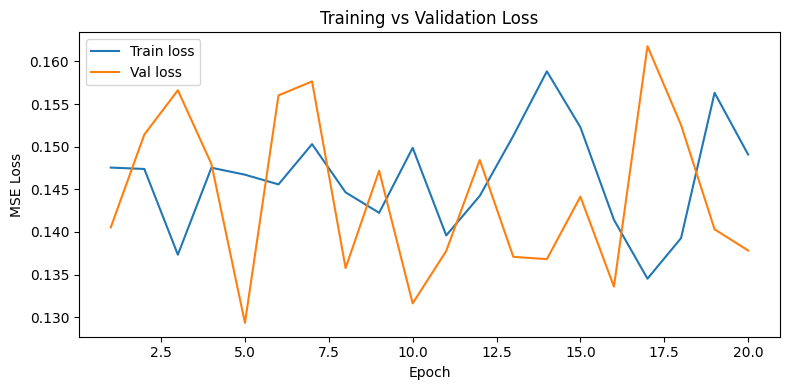

Loss curve saved.


In [11]:

# plot loss curve
import pandas as pd
import matplotlib.pyplot as plt

log = pd.read_csv(OUTPUT_DIR / "loss_log_C.csv")

plt.figure(figsize=(8, 4))
plt.plot(log["epoch"], log["train_loss"], label="Train loss")
plt.plot(log["epoch"], log["val_loss"],   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curve_C.png", dpi=150)
plt.show()
print("Loss curve saved.")